<a href="https://colab.research.google.com/github/OPIM5512-bea13004/A04/blob/Dev-Colab/A04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling with tpot

In [ ]:
!pip install tpot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from tpot import TPOTClassifier
import time
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
#downloading the dataset
df = pd.read_csv("https://drive.google.com/uc?id=1CppeqGbiBzX61jx56gcXyGGDNEeLlJ-W")
print(df.shape)
print(df.info())
print(df.head())
#We can see that we have categorical variables, we also notice that, unfortunately, there are missing values in all but 5 of the 13 columns.
print(df["Loan_Status"].value_counts())
#There appears to be a 70-30 split for the classes of our target variable loan status. This is not as extreme as say a 95-5 split where we would definitely use something like SMOTE.
#However, we should still note this imbalance and may return to address it depending on model results.

df = df.drop(columns=["Loan_ID"]) #Loan ID should not have any predictive power at all so we can drop it.
df = df.dropna() # We keep 78% of the rows if we drop the missing values. Not the best way to handle this, but it might work for our needs

# we will need to modify the dependents column for tpot. We will change 3+ dependents to 4 so the entire column can be numeric
df["Dependents"] = df["Dependents"].replace("3+","4")

LE = LabelEncoder()
y = LE.fit_transform(df["Loan_Status"])
x = df.drop(columns=["Loan_Status"])

x = pd.get_dummies(x, drop_first=False) #df is now all numeric for tpot

#train test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)
#running tpot
start_time = time.time()

tpot = TPOTClassifier(
    generations = 2,
    cv= 5,
    random_state= 42,
    verbose= 2,
    max_time_mins=5
)
tpot.fit(x_train, y_train)
end_time = time.time()
print("TPOT classifier finished in %.2f seconds" %(end_time - start_time))

#best pipeline on test set
y_pred = tpot.predict(x_test)
#evaluations
print("Best pipeline test accuracy:",accuracy_score(y_test, y_pred))
print("\nBest pipeline test confusion matrix:\n",confusion_matrix(y_test, y_pred))
print("\nBest pipeline test classification report:\n",classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/tpot/tpot_estimator/estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:45357
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:44367'


(614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No  

INFO:distributed.scheduler:Register worker addr: tcp://127.0.0.1:44107 name: 0
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:44107
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:55860
INFO:distributed.scheduler:Receive client connection: Client-451e1a88-0f8c-11f1-8766-0242ac1c000c
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:55864
Generation: 100%|██████████| 2/2 [05:00<00:00, 150.38s/it]
INFO:distributed.scheduler:Retire worker addresses (stimulus_id='retire-workers-1771723362.1335404') (0,)
INFO:distributed.nanny:Closing Nanny at 'tcp://127.0.0.1:44367'. Reason: nanny-close
INFO:distributed.nanny:Nanny asking worker to close. Reason: nanny-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:55860; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:44107 name: 0 (stimulus_id='handle-worker-cleanup-1771723362.1461751')
ERROR:distributed.scheduler:Removing worker 

TPOT classifier finished in 309.71 seconds
Best pipeline test accuracy: 0.7083333333333334

Best pipeline test confusion matrix:
 [[19 11]
 [17 49]]

Best pipeline test classification report:
               precision    recall  f1-score   support

           0       0.53      0.63      0.58        30
           1       0.82      0.74      0.78        66

    accuracy                           0.71        96
   macro avg       0.67      0.69      0.68        96
weighted avg       0.73      0.71      0.71        96



# Interpreting tpot results

What sticks out the most is our mediocre recall for actual 0s at 63% and the even worse precision for actual 0s.Everything else is okay. It also looks like our class imbalance comes back to hurt us as our precison and recall for class 1 is much better than for class 0. Our model looks like a SMOTE candidate to fix that class imbalance.

# Permutation importance

Top 5 features Index(['Credit_History', 'Property_Area_Rural', 'Self_Employed_Yes',
       'Property_Area_Urban', 'ApplicantIncome'],
      dtype='object')


Text(0, 0.5, 'Importance')

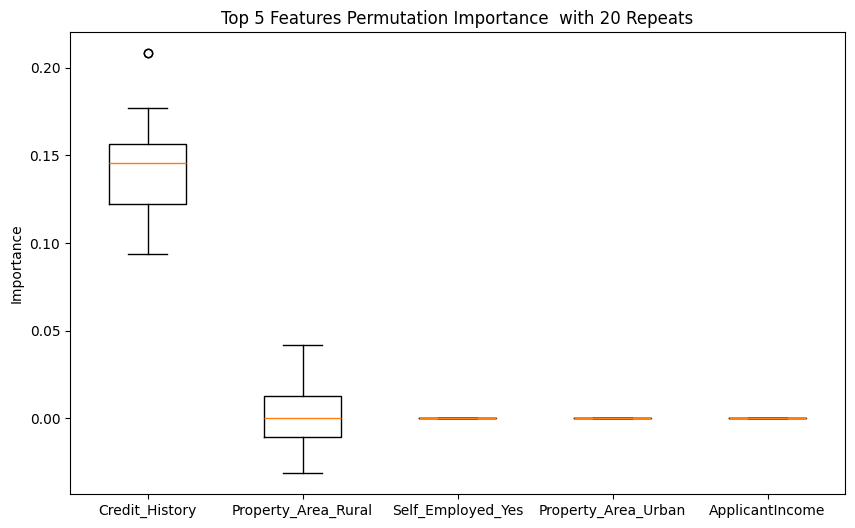

In [ ]:
output_best_model = tpot.fitted_pipeline_
perm_imptnce = permutation_importance(
    output_best_model,
    x_test,
    y_test,
    n_repeats = 20,
    random_state = 42
)
#sort features from largest to smallest
sorted_idx = perm_imptnce.importances_mean.argsort()[::-1]
# top 5 features
top_x_features = x_test.columns[sorted_idx[:5]]
print(f"Top 5 features", top_x_features)

#boxplot
top_5 = sorted_idx[:5]
top5_values = perm_imptnce.importances[top_5].T
plt.figure(figsize=(10, 6))
plt.boxplot(top5_values, tick_labels=top_x_features.tolist())
plt.title("Top 5 Features Permutation Importance  with 20 Repeats")
plt.ylabel("Importance")

Boxplot Takeaways:


*   Clearly credit history is the the most dominant predictor which passes a sanity check. How would you be able to get a loan without any sort of credit history? It makes sense that the smallest drop in accuracy for our 20 repeats is near 0.10
*   We see an outlier for credit_history where a shuffle caused a very large drop in score. If we did more repeats, we should see more outliers.
*   The next most important predictor is property_area_rural, some runs gave us drops in accuracy when shuffled (though not much greater than ~0.04), but we see some runs where it was shuffled actually made the model score better (below zero)
* The fact that we can weakly increase or decrease accuracy accross runs might imply that it is just as useless as the other 3 features which are smack dab at zero.



# PDPs

ValueError: cannot reshape array of size 1 into shape (2)

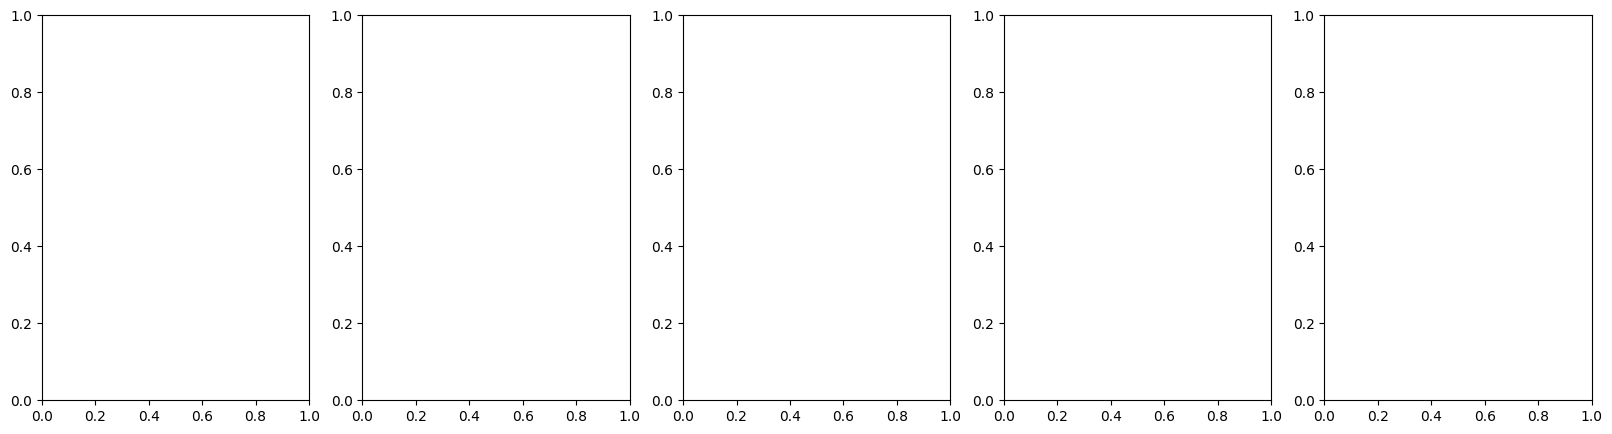

In [ ]:
#pdp

fig, ax = plt.subplots(1, 5, figsize = (20,5))
pdp = PartialDependenceDisplay.from_estimator(
    output_best_model,
    x_test,
    features = list(top_x_features),
    grid_resolution = 10,
    response_method = "auto",
    target = 1,
    method = "brute",
    ax=ax
)
#brute


/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_plot/partial_dependence.py:976: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


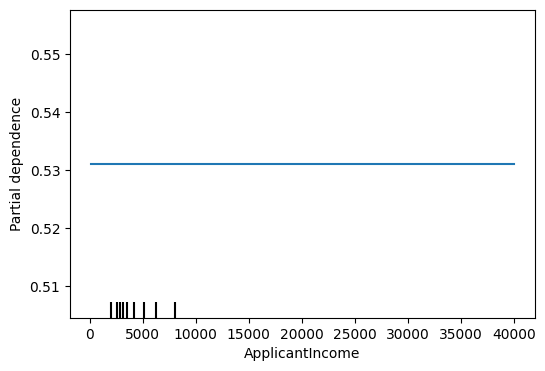

In [ ]:
#there seems to be an issue with how the categorical variables are acting and I get an array of size one. Unfortunately, the only none categorical predictor I have is pretty unimportant in terms of feature importance.
#Here is a PDP for applicantIncome that one cannot gain any insight from really.
fig, ax = plt.subplots(figsize=(6, 4))

PartialDependenceDisplay.from_estimator(
    output_best_model,
    x_test,
    features=['ApplicantIncome'],
    response_method="predict_proba",
    target=1,
    method="brute",
    ax=ax
)

#ApplicantIncome PDP Takeaways

*   Just like our boxplot suggested applicant income is useless for prediction when it comes to our model as the line is completely flat.
*   Another key that applicant income is useless for prediction are the "concentrations" of applicant income that seem to be from  less than 25k to somewhere around 80K. It does not make sense that someone below the poverty line would essentially be predicted to have the same chance of a loan as someone confortably above it.

